# Student Performance — Mixed Naïve Bayes
**GIK Institute | Inferential Statistics Project**

Group: Talal Tariq 2024633 · Basim Malik 2024139 · Rohan Jamshaid 2024442 · Abdul Kabeer 2024288

In [1]:
import numpy as np
import pandas as pd
import math, json, os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from sklearn.naive_bayes import GaussianNB
print("Libraries loaded.")

Libraries loaded.


## 1. Load & Preprocess Data

In [2]:
# Load dataset directly
df = pd.read_csv("data/student_performance_data.csv")
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
df.head()


Loaded: 2392 rows x 15 cols


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
# Create target variable
def map_grade(g):
    if g in (0,1): return 'High'
    elif g == 2:   return 'Medium'
    else:          return 'Low'

df['Performance'] = df['GradeClass'].apply(map_grade)
print(df['Performance'].value_counts())

Performance
Low       1625
Medium     391
High       376
Name: count, dtype: int64


In [4]:
FEATURES = ['StudyTimeWeekly','Absences','Tutoring','ParentalSupport',
            'Extracurricular','Gender','Ethnicity','ParentalEducation','GPA']
CATEGORICAL = ['Gender','Ethnicity','ParentalEducation','ParentalSupport']
GAUSSIAN_IDX  = [0, 1, 8]
BERNOULLI_IDX = [2, 4]
CATEGORICAL_IDX = [3, 5, 6, 7]

df_enc = df.copy()
for col in CATEGORICAL:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X = df_enc[FEATURES].values.astype(float)
y = df_enc['Performance'].values

# Train/test split (no sklearn)
rng = np.random.RandomState(42)
idx = rng.permutation(len(X))
n_test = int(np.ceil(0.2 * len(X)))
X_train, X_test = X[idx[n_test:]], X[idx[:n_test]]
y_train, y_test = y[idx[n_test:]], y[idx[:n_test]]
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1913, Test: 479


## 2. Probabilistic Modeling — Bayesian Network

Naïve Bayes structure: P(Y,X₁…X₉) = P(Y) × ∏ P(Xᵢ|Y)

Feature types:
- **Gaussian**: StudyTimeWeekly, Absences, GPA
- **Bernoulli**: Tutoring, Extracurricular  
- **Categorical (Laplace-smoothed)**: Gender, Ethnicity, ParentalEducation, ParentalSupport

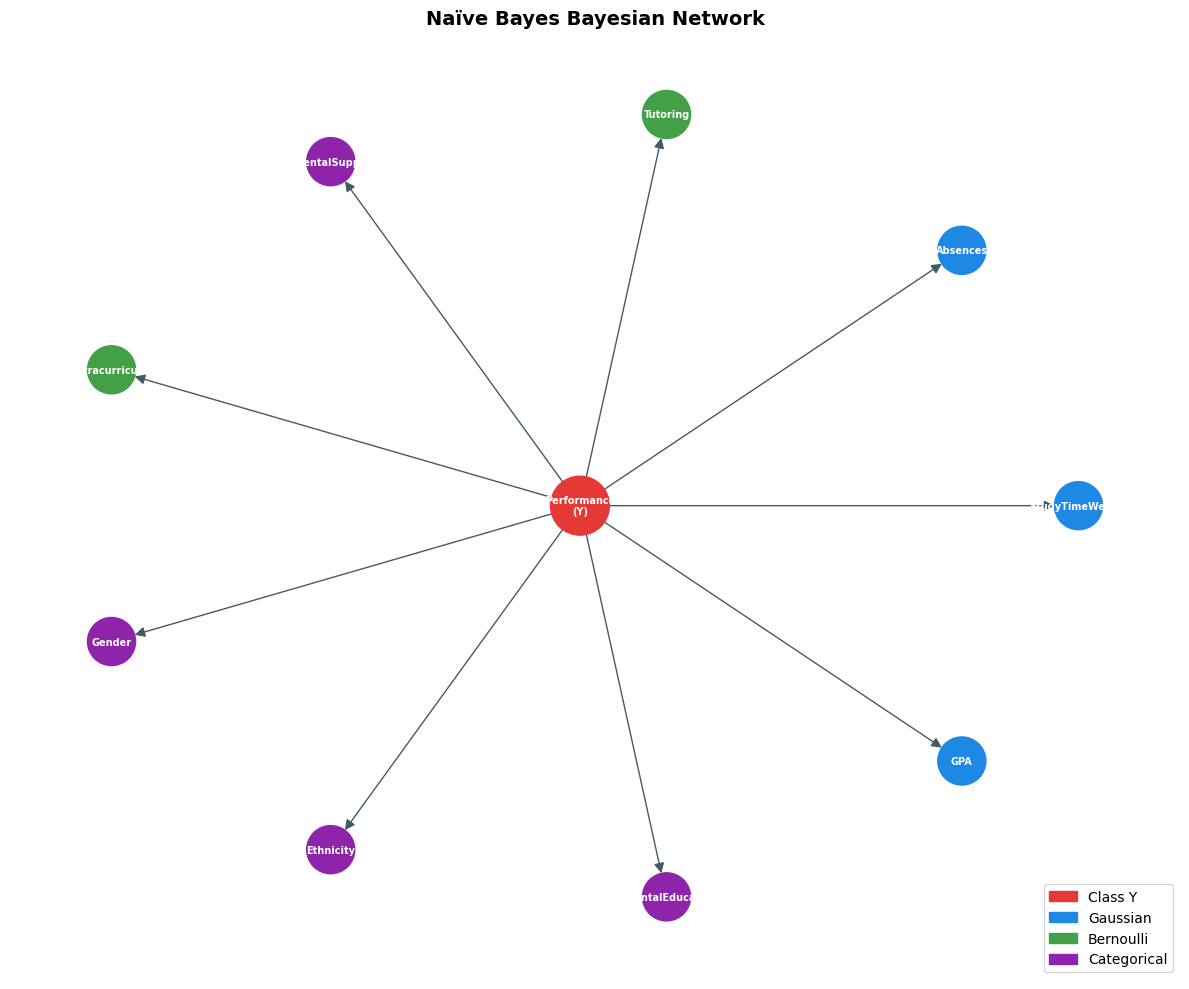

In [5]:
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
# Bayesian Network Plot
G = nx.DiGraph()
G.add_node('Performance\n(Y)')
colors_map = {'StudyTimeWeekly':'#1E88E5','Absences':'#1E88E5','GPA':'#1E88E5',
              'Tutoring':'#43A047','Extracurricular':'#43A047',
              'Gender':'#8E24AA','Ethnicity':'#8E24AA','ParentalEducation':'#8E24AA','ParentalSupport':'#8E24AA'}
for f in FEATURES:
    G.add_node(f); G.add_edge('Performance\n(Y)', f)
n = len(FEATURES)
angles = [2*np.pi*i/n for i in range(n)]
pos = {'Performance\n(Y)':(0,0)}
for f,a in zip(FEATURES, angles): pos[f] = (2.5*np.cos(a), 2.5*np.sin(a))
nc = ['#E53935' if nd=='Performance\n(Y)' else colors_map.get(nd,'#1E88E5') for nd in G.nodes()]
plt.figure(figsize=(12,10))
nx.draw_networkx(G, pos, node_color=nc, node_size=[1800 if n=='Performance\n(Y)' else 1200 for n in G.nodes()],
                 font_size=7, font_color='white', font_weight='bold', edge_color='#455A64', arrows=True, arrowsize=15)
legend = [mpatches.Patch(color='#E53935',label='Class Y'),mpatches.Patch(color='#1E88E5',label='Gaussian'),
          mpatches.Patch(color='#43A047',label='Bernoulli'),mpatches.Patch(color='#8E24AA',label='Categorical')]
plt.legend(handles=legend, loc='lower right'); plt.title('Naïve Bayes Bayesian Network', fontsize=14, fontweight='bold')
plt.axis('off'); plt.tight_layout(); plt.savefig('plots/bayesian_network.png',dpi=150,bbox_inches='tight'); plt.show()

## 3. Independence Analysis

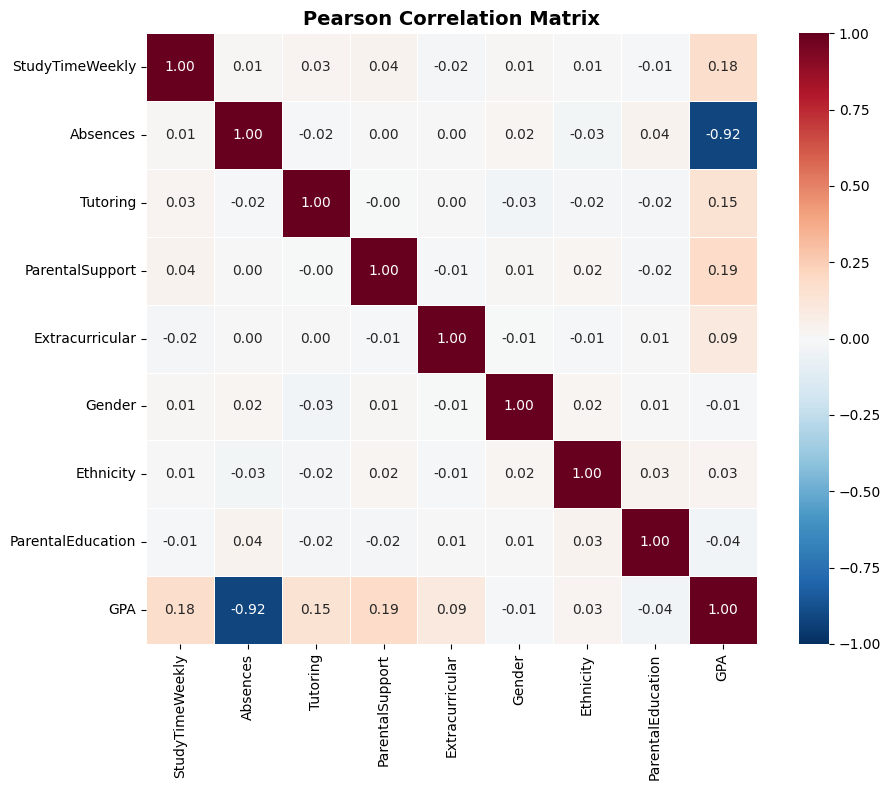

Correlated pairs (|r|>0.25):
  Absences × GPA: r=-0.919


In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10,8))
corr = df_enc[FEATURES].astype(float).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/correlation_heatmap.png',dpi=150,bbox_inches='tight'); plt.show()
print("Correlated pairs (|r|>0.25):")
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        r = corr.iloc[i,j]
        if abs(r)>0.25: print(f"  {FEATURES[i]} × {FEATURES[j]}: r={r:.3f}")

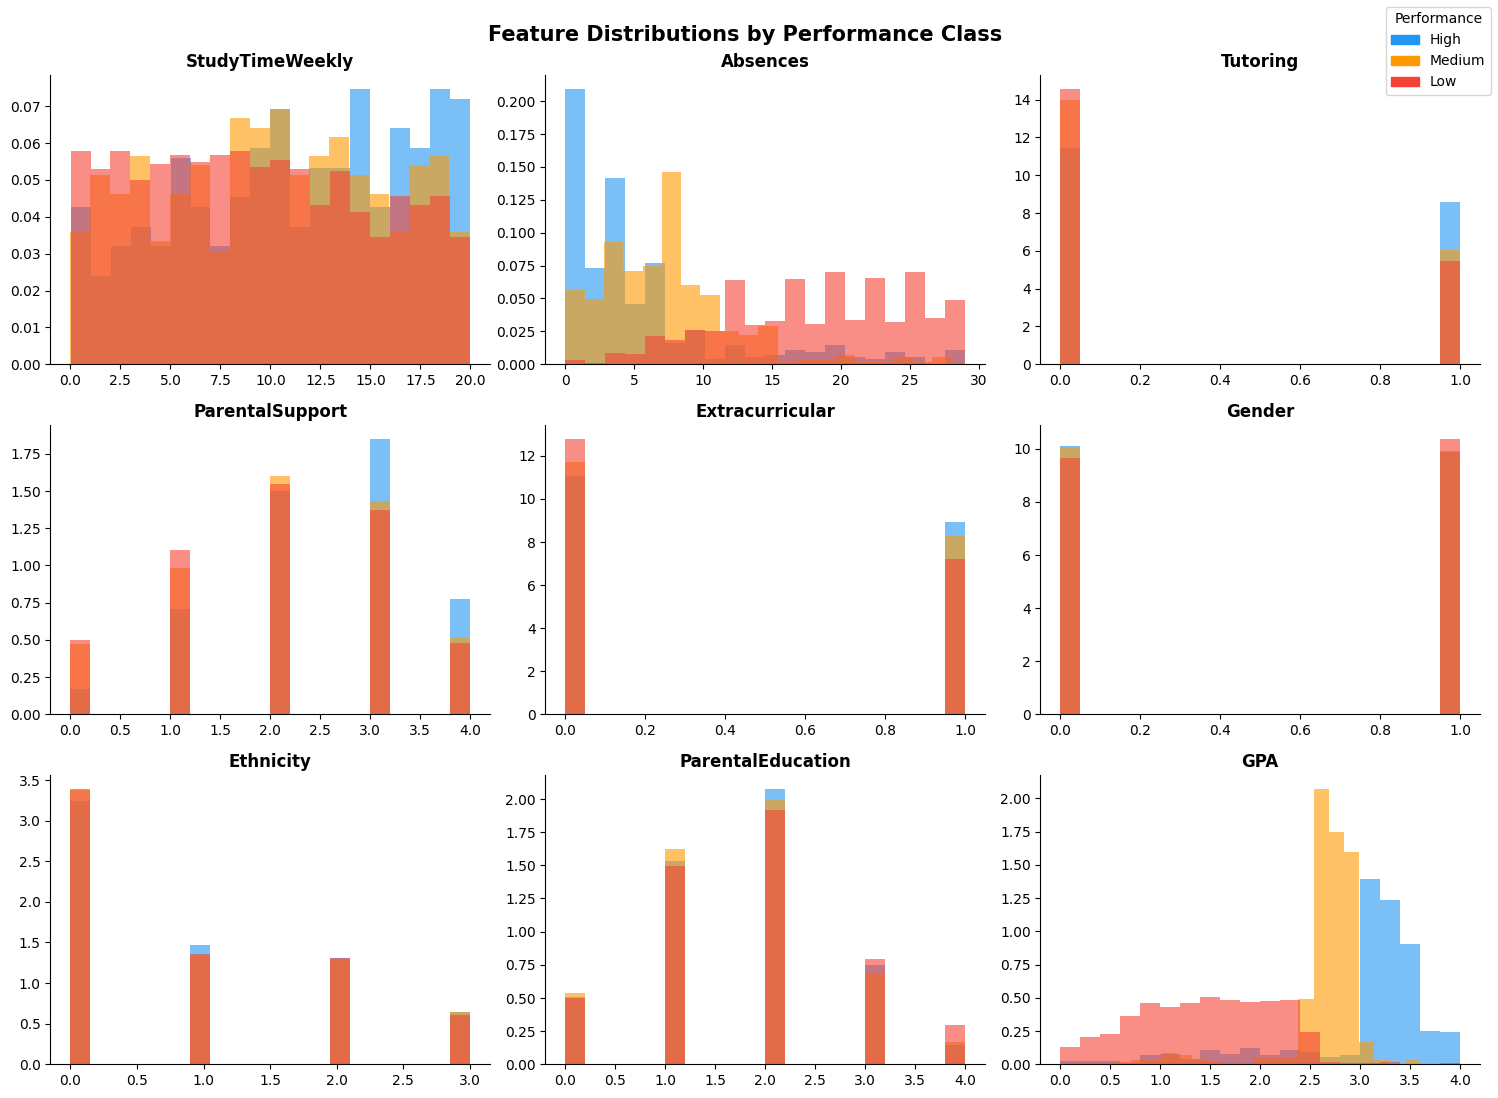

In [7]:
# Feature distributions
fig, axes = plt.subplots(3,3,figsize=(15,11))
palette = {'High':'#2196F3','Medium':'#FF9800','Low':'#F44336'}
for ax, feat in zip(axes.flat, FEATURES):
    for cls, col in palette.items():
        subset = df.loc[df['Performance']==cls, feat].dropna()
        ax.hist(subset.values, bins=20, alpha=0.6, color=col, label=cls, density=True)
    ax.set_title(feat, fontweight='bold'); ax.spines[['top','right']].set_visible(False)
handles=[mpatches.Patch(color=c,label=l) for l,c in palette.items()]
fig.legend(handles=handles, loc='upper right', title='Performance')
plt.suptitle('Feature Distributions by Performance Class', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('plots/feature_distributions.png',dpi=150,bbox_inches='tight'); plt.show()

## 4. Mixed Naïve Bayes — From Scratch

In [8]:
def separate_by_class(X, y):
    return {lbl: X[y==lbl] for lbl in np.unique(y)}

def summarize_dataset(X):
    stats = {'gaussian':{}, 'bernoulli':{}, 'categorical':{}}
    for i in GAUSSIAN_IDX:
        col = X[:,i].astype(float)
        stats['gaussian'][i] = (float(col.mean()), max(float(col.std(ddof=0)),1e-9))
    for i in BERNOULLI_IDX:
        col = X[:,i].astype(float)
        stats['bernoulli'][i] = (col.sum()+1.0)/(len(col)+2.0)
    for i in CATEGORICAL_IDX:
        col = X[:,i].astype(int); K = len(np.unique(col)); n = len(col)
        stats['categorical'][i] = {int(v):(int((col==v).sum())+1.0)/(n+K) for v in np.unique(col)}
    return stats

def calculate_probability(x, mean, std):
    return (1.0/(math.sqrt(2*math.pi)*std))*math.exp(-((x-mean)**2)/(2*std**2))

def calculate_class_probabilities(summaries, row, class_counts, total):
    log_probs = {}
    for lbl, stats in summaries.items():
        lp = math.log(max(class_counts[lbl]/total, 1e-300))
        for i,(mean,std) in stats['gaussian'].items():
            lp += math.log(max(calculate_probability(float(row[i]),mean,std),1e-300))
        for i,p in stats['bernoulli'].items():
            x=float(row[i]); lp += math.log(max(p**x*(1-p)**(1-x),1e-300))
        for i,probs in stats['categorical'].items():
            lp += math.log(max(probs.get(int(row[i]),1e-9),1e-300))
        log_probs[lbl] = lp
    return log_probs

def predict(summaries, row, class_counts, total):
    return max(calculate_class_probabilities(summaries,row,class_counts,total), key=lambda k: calculate_class_probabilities(summaries,row,class_counts,total)[k])

def get_predictions(summaries, X_test, class_counts, total):
    return [predict(summaries,row,class_counts,total) for row in X_test]

def accuracy_score(y_true, y_pred):
    return sum(t==p for t,p in zip(y_true,y_pred))/len(y_true)

print("Functions defined.")

Functions defined.


In [9]:
# Train
separated = separate_by_class(X_train, y_train)
summaries = {lbl: summarize_dataset(rows) for lbl,rows in separated.items()}
class_counts = {lbl: len(rows) for lbl,rows in separated.items()}
total = len(y_train)

# Predict
y_pred_scratch = get_predictions(summaries, X_test, class_counts, total)
acc_scratch = accuracy_score(y_test, y_pred_scratch)

# sklearn comparison
sk = GaussianNB().fit(X_train, y_train)
y_pred_sklearn = list(sk.predict(X_test))
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Scratch accuracy : {acc_scratch*100:.2f}%")
print(f"sklearn accuracy : {acc_sklearn*100:.2f}%")
print(f"Delta            : {abs(acc_scratch-acc_sklearn)*100:.2f}%")

Scratch accuracy : 86.01%
sklearn accuracy : 85.59%
Delta            : 0.42%


## 5. Information Flow in Bayesian Networks

In [10]:
# Empirical information flow
perf = df['Performance']; study = df['StudyTimeWeekly']; absences = df['Absences']

p_high = (perf=='High').mean()
p_study_high = (study>10).mean()
p_abs_high = (absences>10).mean()
mask_study = study>10
p_high_given_study = (perf[mask_study]=='High').mean()
mask_high = perf=='High'
p_study_given_high = (study[mask_high]>10).mean()
p_abs_given_high = (absences[mask_high]>10).mean()

print(f"(a) Causal Flow: P(High|HighStudy)={p_high_given_study:.4f} vs prior {p_high:.4f}")
print(f"(b) Evidential : P(HighStudy|High)={p_study_given_high:.4f} vs prior {p_study_high:.4f}")
print(f"                P(HighAbs|High)   ={p_abs_given_high:.4f} vs prior {p_abs_high:.4f}")

mask_high_gpa = (df['GPA']>3.0) & (perf=='High')
p_study_high_gpa = (study[mask_high_gpa]>10).mean()
print(f"(c) Explaining Away: P(HighStudy|High,GPA>3)={p_study_high_gpa:.4f} vs P(HighStudy|High)={p_study_given_high:.4f}")

(a) Causal Flow: P(High|HighStudy)=0.1950 vs prior 0.1572
(b) Evidential : P(HighStudy|High)=0.5984 vs prior 0.4824
                P(HighAbs|High)   =0.1463 vs prior 0.6467
(c) Explaining Away: P(HighStudy|High,GPA>3)=0.6271 vs P(HighStudy|High)=0.5984


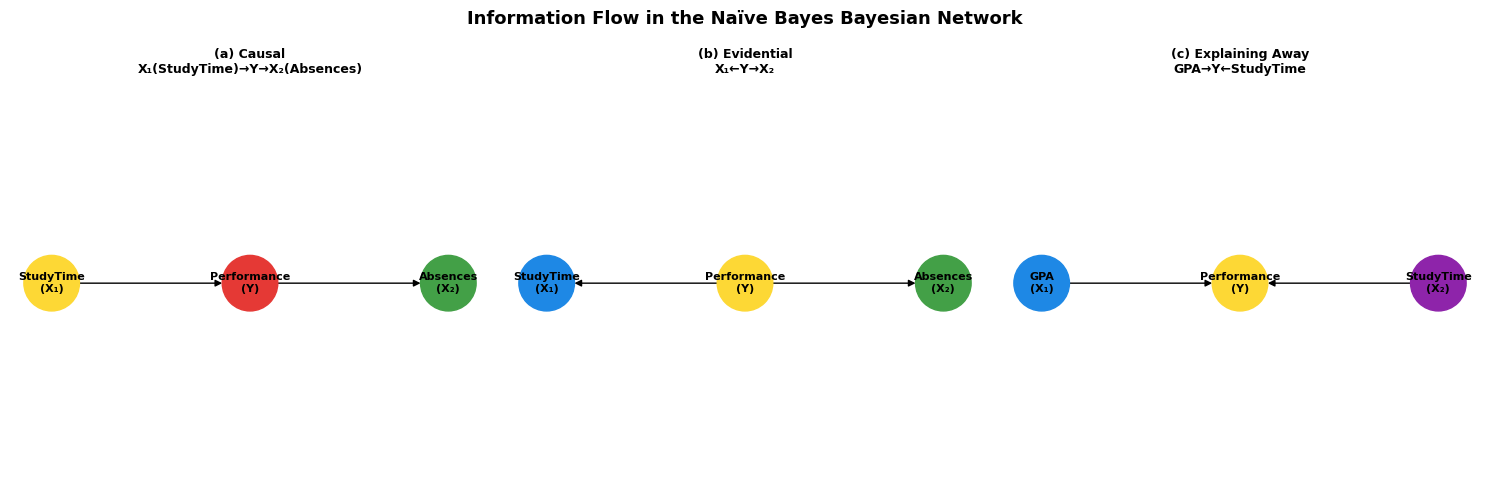

In [11]:
# Information flow plot
# inline version
fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Information Flow in the Naïve Bayes Bayesian Network', fontsize=13, fontweight='bold')
configs = [
    {'title':'(a) Causal\nX₁(StudyTime)→Y→X₂(Absences)','nodes':['StudyTime\n(X₁)','Performance\n(Y)','Absences\n(X₂)'],'edges':[(0,1),(1,2)],'obs':0,'colors':['#1E88E5','#E53935','#43A047']},
    {'title':'(b) Evidential\nX₁←Y→X₂','nodes':['StudyTime\n(X₁)','Performance\n(Y)','Absences\n(X₂)'],'edges':[(1,0),(1,2)],'obs':1,'colors':['#1E88E5','#E53935','#43A047']},
    {'title':'(c) Explaining Away\nGPA→Y←StudyTime','nodes':['GPA\n(X₁)','Performance\n(Y)','StudyTime\n(X₂)'],'edges':[(0,1),(2,1)],'obs':1,'colors':['#1E88E5','#E53935','#8E24AA']},
]
for ax,cfg in zip(axes,configs):
    G2=nx.DiGraph(); G2.add_nodes_from(range(3)); G2.add_edges_from(cfg['edges'])
    pos2={0:(0,0),1:(1,0),2:(2,0)}
    nc2=list(cfg['colors']); nc2[cfg['obs']]='#FDD835'
    nx.draw_networkx(G2,pos2,ax=ax,node_color=nc2,node_size=1600,
                     labels={i:cfg['nodes'][i] for i in range(3)},font_size=8,font_weight='bold')
    ax.set_title(cfg['title'],fontsize=9,fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig('plots/information_flow.png',dpi=150,bbox_inches='tight'); plt.show()

## 6. Results & Confusion Matrices

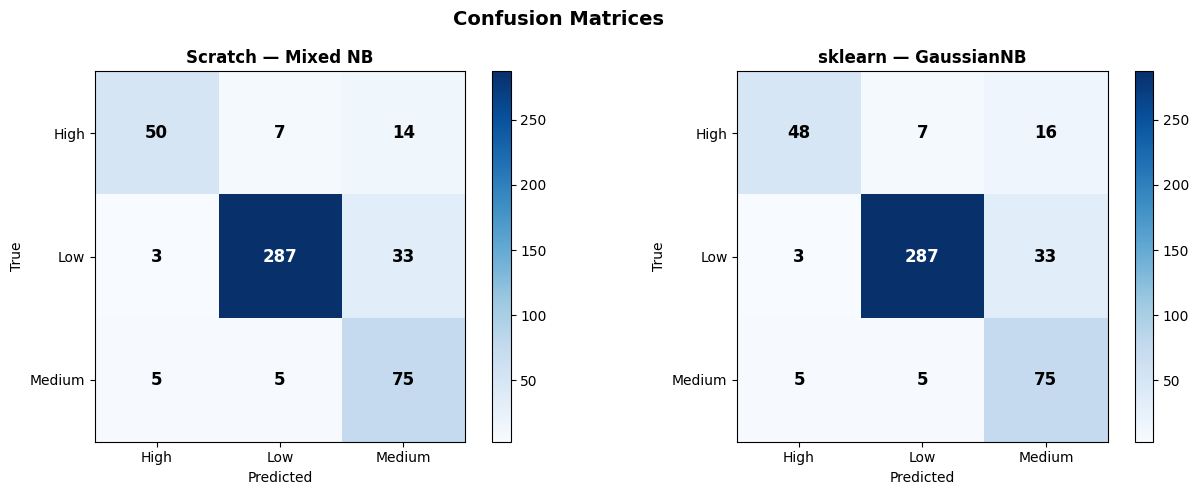

In [12]:
# Confusion matrix
class_labels = sorted(np.unique(y).tolist())
def conf_matrix(y_true, y_pred, labels):
    idx={l:i for i,l in enumerate(labels)}; n=len(labels)
    cm=np.zeros((n,n),dtype=int)
    for t,p in zip(y_true,y_pred): cm[idx[t]][idx[p]]+=1
    return cm

cm_scratch = conf_matrix(y_test, y_pred_scratch, class_labels)
cm_sklearn  = conf_matrix(y_test, y_pred_sklearn,  class_labels)

fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,cm,title in zip(axes,[cm_scratch,cm_sklearn],['Scratch — Mixed NB','sklearn — GaussianNB']):
    im=ax.imshow(cm,cmap='Blues'); ax.set_title(title,fontweight='bold')
    ax.set_xticks(range(len(class_labels))); ax.set_yticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels); ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',
                    color='white' if cm[i,j]>cm.max()*0.5 else 'black',fontsize=12,fontweight='bold')
    plt.colorbar(im,ax=ax,fraction=0.046)
fig.suptitle('Confusion Matrices',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('plots/confusion_matrices.png',dpi=150,bbox_inches='tight'); plt.show()

In [13]:
# Per-class report & accuracy bar
def class_report(y_true, y_pred, labels):
    cm=conf_matrix(y_true,y_pred,labels); r={}
    for i,l in enumerate(labels):
        tp=cm[i,i]; fp=cm[:,i].sum()-tp; fn=cm[i,:].sum()-tp
        prec=tp/(tp+fp) if tp+fp>0 else 0; rec=tp/(tp+fn) if tp+fn>0 else 0
        f1=2*prec*rec/(prec+rec) if prec+rec>0 else 0
        r[l]={'precision':round(prec,4),'recall':round(rec,4),'f1':round(f1,4),'support':int(cm[i,:].sum())}
    return r

rep_scratch = class_report(y_test, y_pred_scratch, class_labels)
rep_sklearn  = class_report(y_test, y_pred_sklearn,  class_labels)
print(f"{'Class':<10} {'Prec':>8} {'Rec':>8} {'F1':>8} {'Sup':>8}")
print('-'*45)
for l,m in rep_scratch.items():
    print(f"{l:<10} {m['precision']:>8.4f} {m['recall']:>8.4f} {m['f1']:>8.4f} {m['support']:>8}")

Class          Prec      Rec       F1      Sup
---------------------------------------------
High         0.8621   0.7042   0.7752       71
Low          0.9599   0.8885   0.9228      323
Medium       0.6148   0.8824   0.7246       85


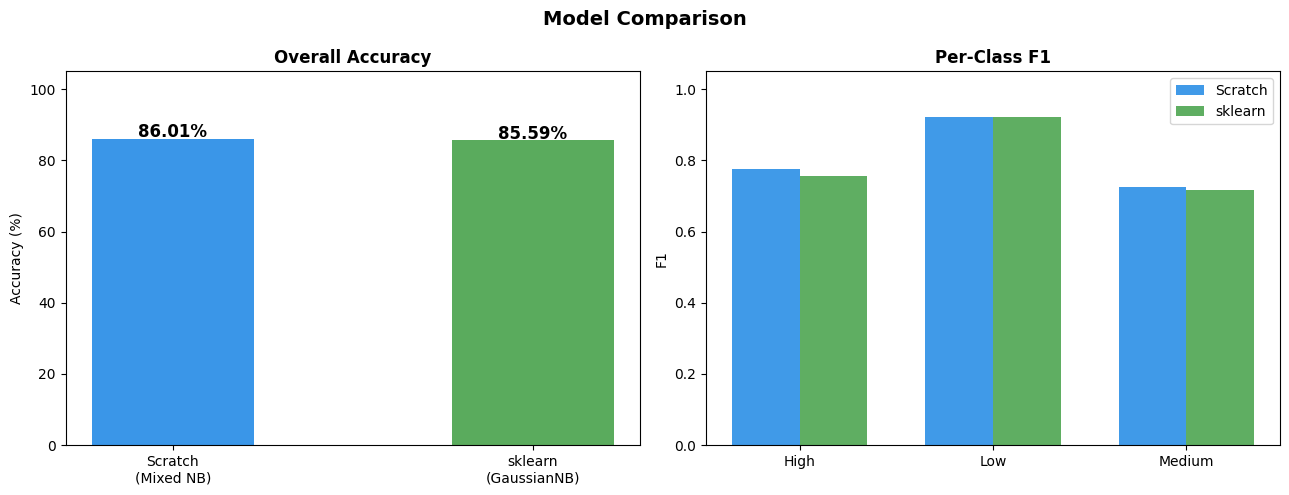

In [14]:
# Accuracy comparison plot
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].bar(['Scratch\n(Mixed NB)','sklearn\n(GaussianNB)'],[acc_scratch*100,acc_sklearn*100],
             color=['#1E88E5','#43A047'],alpha=0.88,width=0.45)
for i,(acc,label) in enumerate([(acc_scratch,'Scratch'),(acc_sklearn,'sklearn')]):
    axes[0].text(i,acc*100+0.5,f'{acc*100:.2f}%',ha='center',fontsize=12,fontweight='bold')
axes[0].set_ylim(0,105); axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Overall Accuracy',fontweight='bold')
x=np.arange(len(class_labels)); w=0.35
axes[1].bar(x-w/2,[rep_scratch[l]['f1'] for l in class_labels],w,label='Scratch',color='#1E88E5',alpha=0.85)
axes[1].bar(x+w/2,[rep_sklearn[l]['f1'] for l in class_labels], w,label='sklearn', color='#43A047',alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(class_labels); axes[1].set_ylim(0,1.05)
axes[1].set_ylabel('F1'); axes[1].set_title('Per-Class F1',fontweight='bold'); axes[1].legend()
plt.suptitle('Model Comparison',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('plots/accuracy_comparison.png',dpi=150,bbox_inches='tight'); plt.show()

## 7. Save results.json

In [15]:
results = {
    "dataset_name": "Students Performance Dataset (Kaggle - rabieelkharoua)",
    "num_samples": str(len(df)),
    "features": FEATURES,
    "accuracy_scratch": str(round(acc_scratch, 6)),
    "accuracy_sklearn": str(round(acc_sklearn, 6)),
    "selected_features": FEATURES,
    "removed_features": [],
    "observations": (
        f"Mixed Naive Bayes from scratch achieved {acc_scratch*100:.2f}% accuracy using "
        f"Gaussian likelihoods for continuous features (StudyTimeWeekly, Absences, GPA), "
        f"Bernoulli likelihoods for binary features (Tutoring, Extracurricular), and "
        f"Categorical likelihoods for discrete features (Gender, Ethnicity, ParentalEducation, "
        f"ParentalSupport). sklearn GaussianNB achieved {acc_sklearn*100:.2f}%. "
        f"The difference of {abs(acc_scratch-acc_sklearn)*100:.2f}% reflects the more "
        f"theoretically appropriate treatment of binary and categorical features. "
        f"Information flow analysis demonstrated causal, evidential, and explaining-away "
        f"effects using StudyTimeWeekly, Performance, Absences, and GPA."
    )
}
os.makedirs("results", exist_ok=True)
with open("results/results.json", "w") as f: json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))


{
  "dataset_name": "Students Performance Dataset (Kaggle - rabieelkharoua)",
  "num_samples": "2392",
  "features": [
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "GPA"
  ],
  "accuracy_scratch": "0.860125",
  "accuracy_sklearn": "0.85595",
  "selected_features": [
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "GPA"
  ],
  "removed_features": [],
  "observations": "Mixed Naive Bayes from scratch achieved 86.01% accuracy using Gaussian likelihoods for continuous features (StudyTimeWeekly, Absences, GPA), Bernoulli likelihoods for binary features (Tutoring, Extracurricular), and Categorical likelihoods for discrete features (Gender, Ethnicity, ParentalEducation, ParentalSupport). sklearn GaussianNB achieved 85.59%. The difference of 0.42% reflects the more the